Dataset root: /home/emilio/Desktop/TESIS/data/raw/chest_xray
Existe: True


## 1. Conteo por split y clase

Recorrer `train`, `val` (si existe) y `test` y contar imágenes por clase.

Conteo de imágenes por split y clase:

  train: {'NORMAL': 1341, 'PNEUMONIA': 3875} → total 5216
  val: {'NORMAL': 8, 'PNEUMONIA': 8} → total 16
  test: {'NORMAL': 234, 'PNEUMONIA': 390} → total 624

Total global: 5856


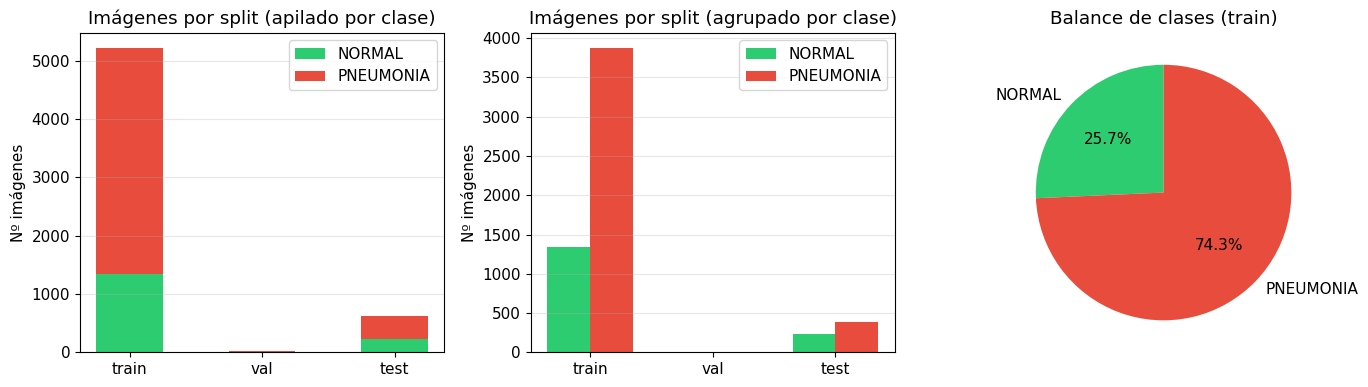

In [7]:
# Gráficos de conteo por split y clase
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) Barras apiladas por split (cada color = una clase)
splits_ok = [s for s in splits if s in counts]
x = np.arange(len(splits_ok))
width = 0.5
classes = sorted(set().union(*(set(counts[s].keys()) for s in splits_ok)))
bottom = np.zeros(len(splits_ok))
colors = {"NORMAL": "#2ecc71", "PNEUMONIA": "#e74c3c"}
for cls in classes:
    vals = [counts[s].get(cls, 0) for s in splits_ok]
    axes[0].bar(x, vals, width, label=cls, bottom=bottom, color=colors.get(cls, "gray"))
    bottom += vals
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits_ok)
axes[0].set_ylabel("Nº imágenes")
axes[0].set_title("Imágenes por split (apilado por clase)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# 2) Barras agrupadas por split
x = np.arange(len(splits_ok))
w = 0.35
for i, cls in enumerate(classes):
    vals = [counts[s].get(cls, 0) for s in splits_ok]
    axes[1].bar(x + (i - 0.5) * w, vals, w, label=cls, color=colors.get(cls, "gray"))
axes[1].set_xticks(x)
axes[1].set_xticklabels(splits_ok)
axes[1].set_ylabel("Nº imágenes")
axes[1].set_title("Imágenes por split (agrupado por clase)")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

# 3) Proporción de clases (train)
train_tot = sum(counts["train"].values()) if "train" in counts else 0
if train_tot > 0:
    sizes = [counts["train"].get(c, 0) for c in classes]
    axes[2].pie(sizes, labels=classes, autopct="%1.1f%%", colors=[colors.get(c, "gray") for c in classes], startangle=90)
    axes[2].set_title("Balance de clases (train)")
plt.tight_layout()
plt.show()

### Muestras visuales por clase

Rejilla de imágenes de ejemplo para inspección rápida.

In [ ]:
# Rejilla de muestras: una fila por clase (desde train)
n_per_class = 6
fig, axes = plt.subplots(len(classes), n_per_class, figsize=(12, 2 * len(classes)))
if len(classes) == 1:
    axes = axes.reshape(1, -1)
for row, cls in enumerate(classes):
    files = file_lists.get("train", {}).get(cls, [])[:n_per_class]
    for col in range(n_per_class):
        ax = axes[row, col]
        if col < len(files):
            with Image.open(files[col]) as img:
                ax.imshow(img, cmap="gray")
            ax.set_title(f"{cls}" if col == 0 else "", loc="left", fontsize=10)
        ax.axis("off")
plt.suptitle("Muestras de entrenamiento por clase", y=1.02)
plt.tight_layout()
plt.show()

## 2. Formatos y dimensiones

Inspeccionar extensiones y tamaños (ancho × alto) de una muestra; opcionalmente escanear todas para detectar atípicos o corruptas.

Extensiones: {'.jpeg': 2000}
Dimensiones únicas (muestra): [(399, 164), (445, 199), (446, 232), (450, 250), (480, 167), (494, 151), (494, 196), (502, 307), (507, 244), (508, 218), (645, 329), (663, 431), (664, 360), (667, 322), (671, 393), (712, 439), (713, 353), (728, 392), (736, 480), (738, 543)]
  ... y más
Archivos corruptos o no abribles: 0


### Distribución de dimensiones (ancho × alto)

Scatter y histogramas para ver variabilidad de tamaños y relación de aspecto.

In [ ]:
if dimensions:
    ww, hh = zip(*dimensions)
    aspect = [w / h if h else 0 for w, h in dimensions]

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))

    # Scatter ancho vs alto
    axes[0, 0].scatter(ww, hh, alpha=0.4, s=8, c="steelblue", edgecolors="none")
    axes[0, 0].set_xlabel("Ancho (px)")
    axes[0, 0].set_ylabel("Alto (px)")
    axes[0, 0].set_title("Dimensiones de las imágenes (muestra)")
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_aspect("equal", adjustable="box")

    # Histograma ancho
    axes[0, 1].hist(ww, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    axes[0, 1].set_xlabel("Ancho (px)")
    axes[0, 1].set_ylabel("Frecuencia")
    axes[0, 1].set_title("Distribución del ancho")
    axes[0, 1].grid(axis="y", alpha=0.3)

    # Histograma alto
    axes[1, 0].hist(hh, bins=40, color="coral", edgecolor="white", alpha=0.8)
    axes[1, 0].set_xlabel("Alto (px)")
    axes[1, 0].set_ylabel("Frecuencia")
    axes[1, 0].set_title("Distribución del alto")
    axes[1, 0].grid(axis="y", alpha=0.3)

    # Histograma relación de aspecto
    axes[1, 1].hist(aspect, bins=50, color="seagreen", edgecolor="white", alpha=0.8)
    axes[1, 1].axvline(np.median(aspect), color="red", linestyle="--", label=f"Mediana = {np.median(aspect):.2f}")
    axes[1, 1].set_xlabel("Aspect ratio (ancho/alto)")
    axes[1, 1].set_ylabel("Frecuencia")
    axes[1, 1].set_title("Distribución de la relación de aspecto")
    axes[1, 1].legend()
    axes[1, 1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay dimensiones para graficar.")

## 3. Resumen para documentación

Guardar un resumen en `config` (o en un JSON aparte) para usar en la tesis y en notebooks posteriores.

In [4]:
audit_summary = {
    "dataset_root": str(dataset_root),
    "counts": {s: dict(counts[s]) for s in splits if s in counts},
    "totals_per_split": {s: sum(counts[s].values()) for s in splits if s in counts},
    "grand_total": grand_total,
    "extensions": dict(extensions),
    "unique_dimensions_sample": list(sorted(set(dimensions)))[:30],
    "corrupt_count": len(corrupt),
}

config.update({"data": {"audit_summary": audit_summary}})
print(json.dumps(audit_summary, indent=2, ensure_ascii=False))

{
  "dataset_root": "/home/emilio/Desktop/TESIS/data/raw/chest_xray",
  "counts": {
    "train": {
      "NORMAL": 1341,
      "PNEUMONIA": 3875
    },
    "val": {
      "NORMAL": 8,
      "PNEUMONIA": 8
    },
    "test": {
      "NORMAL": 234,
      "PNEUMONIA": 390
    }
  },
  "totals_per_split": {
    "train": 5216,
    "val": 16,
    "test": 624
  },
  "grand_total": 5856,
  "extensions": {
    ".jpeg": 2000
  },
  "unique_dimensions_sample": [
    [
      399,
      164
    ],
    [
      445,
      199
    ],
    [
      446,
      232
    ],
    [
      450,
      250
    ],
    [
      480,
      167
    ],
    [
      494,
      151
    ],
    [
      494,
      196
    ],
    [
      502,
      307
    ],
    [
      507,
      244
    ],
    [
      508,
      218
    ],
    [
      645,
      329
    ],
    [
      663,
      431
    ],
    [
      664,
      360
    ],
    [
      667,
      322
    ],
    [
      671,
      393
    ],
    [
      712,
      439
    ],


In [ ]:
# Resumen visual de la auditoría
fig, ax = plt.subplots(figsize=(8, 4))
splits_ok = [s for s in splits if s in counts]
totals = [sum(counts[s].values()) for s in splits_ok]
bars = ax.bar(splits_ok, totals, color=["#3498db", "#9b59b6", "#1abc9c"], edgecolor="white", linewidth=1.2)
ax.set_ylabel("Nº imágenes")
ax.set_title("Total de imágenes por split (resumen auditoría)")
for bar, t in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30, str(t), ha="center", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(totals) * 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Total dataset: {grand_total} imágenes  |  Archivos corruptos: {len(corrupt)}")